C:\Users\vaibh\AppData\Local\Temp\ipykernel_14672\1671673321.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  months = pd.date_range(start='2021-01-01', periods=36, freq='M')
C:\Users\vaibh\AppData\Local\Temp\ipykernel_14672\1671673321.py:76: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(start=df.index[-1], periods=6, freq='M')


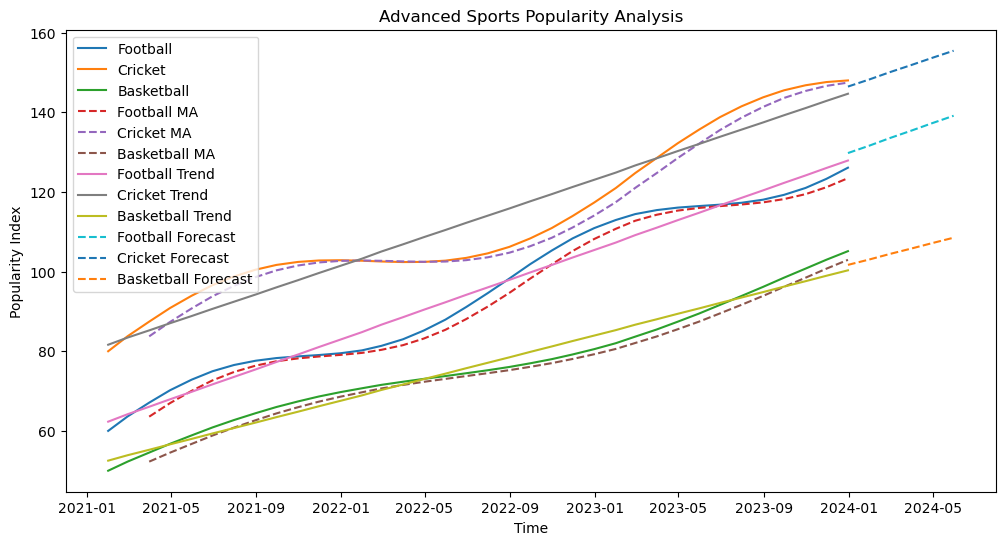

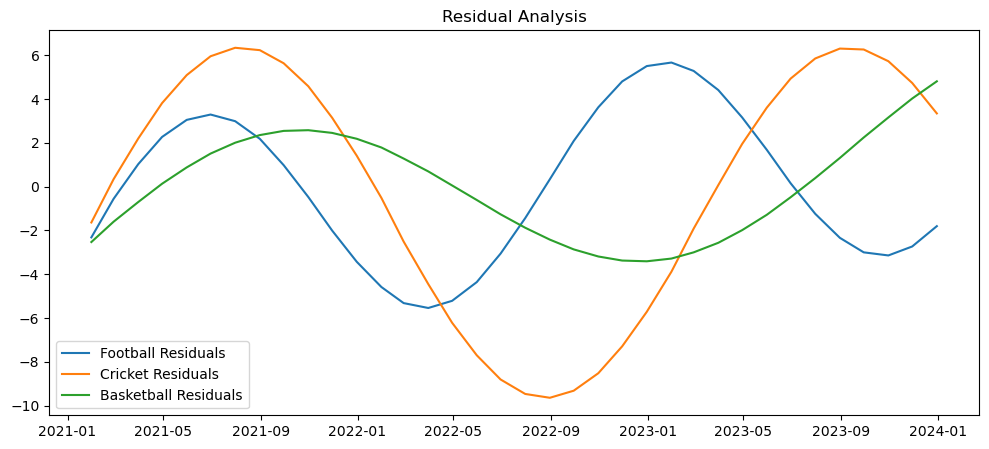

Football R2: 0.971
Cricket R2: 0.92
Basketball R2: 0.974

Trend Equations:
Football: y = 1.87 x + 62.32
Cricket: y = 1.8 x + 81.64
Basketball: y = 1.37 x + 52.53


In [1]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

months = pd.date_range(start='2021-01-01', periods=36, freq='M')

football = []
cricket = []
basketball = []

for i in range(36):
    football.append(60 + 2*i + 5*np.sin(i/3))        # trend + seasonality
    cricket.append(80 + 1.8*i + 8*np.sin(i/4))      # stronger popularity
    basketball.append(50 + 1.5*i + 4*np.sin(i/5))   # slower growth


df = pd.DataFrame({
    'Month': months,
    'Football': football,
    'Cricket': cricket,
    'Basketball': basketball
})

df.set_index('Month', inplace=True)


plt.figure(figsize=(12,6))
plt.plot(df['Football'], label='Football')
plt.plot(df['Cricket'], label='Cricket')
plt.plot(df['Basketball'], label='Basketball')


df['F_MA'] = df['Football'].rolling(3).mean()
df['C_MA'] = df['Cricket'].rolling(3).mean()
df['B_MA'] = df['Basketball'].rolling(3).mean()

plt.plot(df['F_MA'], '--', label='Football MA')
plt.plot(df['C_MA'], '--', label='Cricket MA')
plt.plot(df['B_MA'], '--', label='Basketball MA')


x = np.arange(len(df))


f_coef = np.polyfit(x, df['Football'], 1)
c_coef = np.polyfit(x, df['Cricket'], 1)
b_coef = np.polyfit(x, df['Basketball'], 1)

f_trend = np.polyval(f_coef, x)
c_trend = np.polyval(c_coef, x)
b_trend = np.polyval(b_coef, x)


plt.plot(df.index, f_trend, label='Football Trend')
plt.plot(df.index, c_trend, label='Cricket Trend')
plt.plot(df.index, b_trend, label='Basketball Trend')


f_r2 = r2_score(df['Football'], f_trend)
c_r2 = r2_score(df['Cricket'], c_trend)
b_r2 = r2_score(df['Basketball'], b_trend)


df['F_res'] = df['Football'] - f_trend
df['C_res'] = df['Cricket'] - c_trend
df['B_res'] = df['Basketball'] - b_trend


future_x = np.arange(len(df), len(df)+6)

f_future = np.polyval(f_coef, future_x)
c_future = np.polyval(c_coef, future_x)
b_future = np.polyval(b_coef, future_x)

future_dates = pd.date_range(start=df.index[-1], periods=6, freq='M')

plt.plot(future_dates, f_future, '--', label='Football Forecast')
plt.plot(future_dates, c_future, '--', label='Cricket Forecast')
plt.plot(future_dates, b_future, '--', label='Basketball Forecast')


plt.title('Advanced Sports Popularity Analysis')
plt.xlabel('Time')
plt.ylabel('Popularity Index')
plt.legend()
plt.show()


plt.figure(figsize=(12,5))
plt.plot(df['F_res'], label='Football Residuals')
plt.plot(df['C_res'], label='Cricket Residuals')
plt.plot(df['B_res'], label='Basketball Residuals')
plt.title('Residual Analysis')
plt.legend()
plt.show()


print("Football R2:", round(f_r2,3))
print("Cricket R2:", round(c_r2,3))
print("Basketball R2:", round(b_r2,3))

print("\nTrend Equations:")
print("Football: y =", round(f_coef[0],2), "x +", round(f_coef[1],2))
print("Cricket: y =", round(c_coef[0],2), "x +", round(c_coef[1],2))
print("Basketball: y =", round(b_coef[0],2), "x +", round(b_coef[1],2))